In [ ]:
import typing
import h5py
import numpy as np
import jax.numpy as jnp
from jax import jit
from dataclasses import dataclass
from typing import Optional
from astropy import constants as const
from copy import deepcopy

# Import fsps and check availability
try:
    import fsps
    HAS_FSPS = True
except (ImportError, RuntimeError):
    HAS_FSPS = False

In [39]:
def collect_ssp_data(**kwargs) -> typing.Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Collects Simple Stellar Population (SSP) data using the SSPBasis class and 
    adds an extra SSP with log age -6 because zero age SSPs are not available in FSPS. 

    The new SSP with log age -6 is inserted at the beginning of the age and flux arrays.

    Parameters
    ----------
    **kwargs : dict
        Keyword arguments to configure the SSPBasis object.

    Returns
    -------
    Tuple of jnp.ndarray:
        - ssp_lgmet : 1D array of log10(Z) representing the metallicities.
        - ssp_lg_age_gyr : 1D array of log10(age/Gyr) for the SSP templates, including the new SSP with log age -6.
        - ssp_wave : 1D array of wavelength values for the SSP spectra.
        - ssp_flux : 3D array containing the spectral fluxes for each metallicity, including the new SSP.
    """
    if not HAS_FSPS:
        raise ImportError("FSPS is required for SSP data collection but is not installed.")

    # Initialize
    ssp = fsps.StellarPopulation(zcontinuous=0, sfh=0, **kwargs)

    # Retrieve logarithmic metallicity and age data
    ssp_lgmet = jnp.log10(ssp.zlegend)
    nzmet = ssp_lgmet.size
    ssp_lg_age_gyr = ssp.log_age - 9.0  # Log age in Gyr

    # Identify the index where log age is -4
    age_minus_4_idx = np.where(ssp_lg_age_gyr == -4)[0][0]

    # Collect spectral data for each metallicity
    spectrum_collector = []
    for zmet_indx in range(1, nzmet + 1):
        print(f"...retrieving zmet = {zmet_indx} of {nzmet}")
        _wave, _fluxes = ssp.get_spectrum(tage=0.0, zmet=zmet_indx, peraa=False)
        spectrum_collector.append(_fluxes)


    # Convert collected data to JAX arrays
    ssp_wave = jnp.array(_wave)
    ssp_flux = jnp.array(spectrum_collector)

    # Step 1: Duplicate the SSP with age -4 to create one with age -6
    # Select flux corresponding to log age -4 for all metallicities
    duplicated_flux = ssp_flux[:, age_minus_4_idx, :]  # Shape: (nzmet, wavelength)
    # Step 2: Modify the age to log age -6 and insert it at the beginning of ssp_lg_age_gyr
    new_age = -6
    ssp_lg_age_gyr = np.insert(ssp_lg_age_gyr, 0, new_age)

    # Step 3: Insert the duplicated flux at the beginning of ssp_flux for each metallicity
    ssp_flux = np.concatenate([duplicated_flux[:, np.newaxis, :], ssp_flux], axis=1)

    # Convert the updated arrays to JAX arrays
    ssp_lg_age_gyr = jnp.array(ssp_lg_age_gyr)
    ssp_flux = jnp.array(ssp_flux)

    # Get ionising information
    idx_ion = jnp.searchsorted(ssp_wave, 912.0)
    
    ssp_flux_ion = ssp_flux[:, :, :idx_ion]  # Flux under 912 Angstroms for each metallicity and age
    ssp_wave_ion = ssp_wave[:idx_ion]  # Wavelength under 912 Angstroms

    qq = jnp.trapezoid(ssp_flux_ion/ssp_wave_ion, x = ssp_wave_ion)
    log_qq = jnp.log10(qq / const.h) + jnp.log10(const.L_sun)

    return ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, log_qq



@dataclass(frozen=True)
class SSPData:
    """
    A frozen dataclass to store information about Simple Stellar Population (SSP) templates.

    Attributes:
    -----------
    ssp_lgmet : jnp.ndarray
        1D array of log10(Z) representing the metallicity values of the SSP templates.
        Z is the mass fraction of elements heavier than Helium (He).

    ssp_lg_age_gyr : jnp.ndarray
        1D array of log10(age/Gyr) representing the ages of the SSP templates.

    ssp_wave : jnp.ndarray
        1D array of wavelength values for the SSP spectra.

    ssp_flux : jnp.ndarray
        3D array of shape (n_met, n_ages, n_wave) containing the Spectral Energy 
        Distribution (SED) of the SSP in units of Lsun/Hz. This represents the 
        flux for each combination of metallicity, age, and wavelength.

    ssp_flux_aa : Optional[jnp.ndarray]
        3D array of shape (n_met, n_ages, n_wave) containing the SED of the SSP in
        units of Lsun/AA, but with wavelengths in Angstroms (Å). This is an
        optional attribute that may not be present in all SSP datasets. If not provided,
    """

    ssp_lgmet: jnp.ndarray
    ssp_lg_age_gyr: jnp.ndarray
    ssp_wave: jnp.ndarray
    ssp_flux: jnp.ndarray
    log_qq: jnp.ndarray
    

    def __post_init__(self):
        """Validate the shapes of the SSP data after initialization."""
        if self.ssp_flux.shape != (self.ssp_lgmet.size, self.ssp_lg_age_gyr.size, self.ssp_wave.size):
            raise ValueError(
                f"Shape mismatch: 'ssp_flux' should have shape "
                f"(n_met, n_ages, n_wave), but got {self.ssp_flux.shape}. "
                f"Expected: ({self.ssp_lgmet.size}, {self.ssp_lg_age_gyr.size}, {self.ssp_wave.size})"
            )
    

    def save(self, filename):
        """
        Save the SSPData object to an HDF5 file.

        Parameters:
        -----------
        filename : str
            The file to which the data will be saved.
        """
        with h5py.File(filename, 'w') as f:
            # Save each array as a dataset in the HDF5 file
            f.create_dataset('ssp_lgmet', data=np.array(self.ssp_lgmet))
            f.create_dataset('ssp_lg_age_gyr', data=np.array(self.ssp_lg_age_gyr))
            f.create_dataset('ssp_wave', data=np.array(self.ssp_wave))
            f.create_dataset('ssp_flux', data=np.array(self.ssp_flux))
            f.create_dataset('log_qq', data=np.array(self.log_qq))

    @classmethod
    def load(cls, filename):
        """
        Load the SSPData object from an HDF5 file.

        Parameters:
        -----------
        filename : str
            The file from which the data will be loaded.
        
        Returns:
        --------
        SSPData : SSPData
            An instance of SSPData containing the loaded data.
        """
        with h5py.File(filename, 'r') as f:
            # Load each dataset from the HDF5 file
            ssp_lgmet = jnp.array(f['ssp_lgmet'][:])
            ssp_lg_age_gyr = jnp.array(f['ssp_lg_age_gyr'][:])
            ssp_wave = jnp.array(f['ssp_wave'][:])
            ssp_flux = jnp.array(f['ssp_flux'][:])
            log_qq = jnp.array(f['log_qq'][:])


        return cls(ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, log_qq)

# Default keys for SSPData attributes
DEFAULT_SSP_KEYS = SSPData.__annotations__.keys()


In [17]:
ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, log_qq = collect_ssp_data()

...retrieving zmet = 1 of 12
...retrieving zmet = 2 of 12
...retrieving zmet = 3 of 12
...retrieving zmet = 4 of 12
...retrieving zmet = 5 of 12
...retrieving zmet = 6 of 12
...retrieving zmet = 7 of 12
...retrieving zmet = 8 of 12
...retrieving zmet = 9 of 12
...retrieving zmet = 10 of 12
...retrieving zmet = 11 of 12
...retrieving zmet = 12 of 12


In [40]:
ssp_data = SSPData(ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, log_qq)

ssp_data.save('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

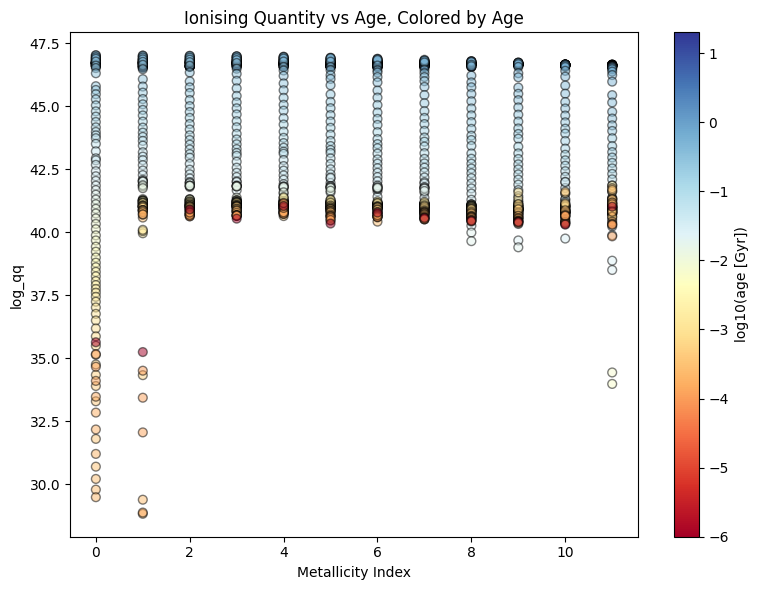

In [44]:
import matplotlib.pyplot as plt

# Assume log_qq has shape (n_met, n_age)
# and ssp_lg_age_gyr is 1D with shape (n_age,)
n_met, n_age = log_qq.shape

# Make a meshgrid for plotting (optional if you want flat color arrays)
ages = ssp_lg_age_gyr  # shape (n_age,)
colors = plt.cm.RdYlBu((ages - ages.min()) / (ages.max() - ages.min()))[::-1]  # normalize

plt.figure(figsize=(8, 6))

for i in range(n_met):
    plt.scatter(np.full(n_age, i), log_qq[i], c=colors, alpha=0.5, s=40, edgecolor='k', label=f'met {i}' if i < 5 else "")

sm = plt.cm.ScalarMappable(cmap='RdYlBu', norm=plt.Normalize(vmin=ages.min(), vmax=ages.max()))
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('log10(age [Gyr])')

plt.xlabel('Metallicity Index')
plt.ylabel('log_qq')
plt.title('Ionising Quantity vs Age, Colored by Age')
plt.tight_layout()
plt.show()